In [1]:
import tensorflow as tf
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np
import os

c:\Users\ferdy\development\anaconda\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
img_size = (224, 224)
batch_size = 32

In [3]:
model = tf.keras.models.load_model('../../model/soil_texture_classifier.h5')

In [4]:
class_names = os.listdir('../../dataset_split/train')

In [5]:
def predict_image(img_path):
    img = Image.open(img_path).convert("RGB").resize(img_size)
    img_array = np.array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)

    prediction = model.predict(img_array)
    predicted_class = class_names[np.argmax(prediction)]
    confidence = np.max(prediction)

    print(f"Predicted Class: {predicted_class} ({confidence:.2%})")

    plt.imshow(img)
    plt.title(f"Prediction: {predicted_class} ({confidence:.2%})")
    plt.axis('off')
    plt.show()

1/1 [==============================] - 3s 3s/step
Predicted Class: 03_loamy (77.39%)


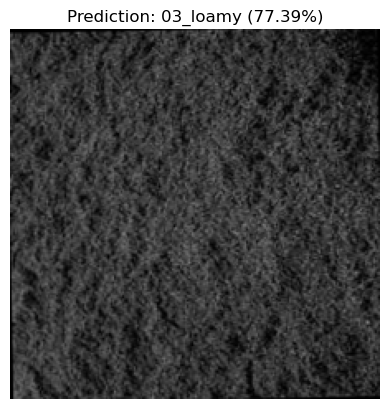

In [6]:
image = '../../dataset_split/test/03_loamy/Black_1_jpg.rf.c456fea9ea39ddf3e2b60c76cb981f30.jpg'

predict_image(image)